# Clase 1 · Fundamentos de la ciencia de datos

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

Este notebook corre en el entorno local del curso (guía de instalación del repositorio). Si prefiere no instalar nada, use la versión para Google Colab del repositorio.

Objetivos de la sesión: comprobar que el entorno funciona y explorar un conjunto de datos real, la Encuesta Origen Destino de Santiago 2012 (EOD), aplicando el concepto central de la clase: cada columna de una tabla es una variable de cierto tipo, y el tipo determina qué análisis es válido.

## 1. Verificación del entorno

Si esta celda corre sin errores y muestra las versiones, está todo en orden.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy      ", np.__version__)
print("Pandas     ", pd.__version__)
print("Matplotlib ", matplotlib.__version__)

NumPy       2.5.2
Pandas      3.0.5
Matplotlib  3.11.1


## 2. NumPy: cálculo sobre arreglos completos

NumPy aporta el arreglo (`array`): una colección de números sobre la que las operaciones se aplican completas, sin escribir ciclos. A eso se le llama vectorización, y es la base de todo el ecosistema: Pandas y Matplotlib trabajan sobre arreglos de NumPy.

Estos cinco valores son duraciones de viaje, en minutos:

In [2]:
tiempos = np.array([70, 105, 90, 25, 40])

print("Media:  ", tiempos.mean(), "minutos")
print("Máximo: ", tiempos.max(), "minutos")
print("En horas:", tiempos / 60)

Media:   66.0 minutos
Máximo:  105 minutos
En horas: [1.16666667 1.75       1.5        0.41666667 0.66666667]


La división `tiempos / 60` se aplicó a los cinco valores de una vez. Con cinco números da lo mismo; con los cientos de miles de filas de una encuesta, la diferencia de velocidad y de claridad del código es considerable.

## 3. Pandas: abrir una tabla real

Pandas aporta el `DataFrame`: una tabla con columnas etiquetadas, cada una de su propio tipo. Vamos a abrir la tabla de viajes de la EOD 2012 directo desde una URL.

Dos detalles del archivo: los campos van separados por punto y coma (`sep=";"`) y los decimales usan coma (`decimal=","`). El archivo pesa unos 15 MB, así que la descarga puede tomar algunos segundos.

In [3]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/cienciadatos/"
    "main/datos/eod_stgo/"
)
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)

viajes.shape

(113591, 35)

113.591 filas: una por viaje registrado. Las tres miradas iniciales a cualquier tabla nueva son `shape` (dimensiones), `head` (primeras filas) e `info` (columnas, tipos y valores presentes).

In [4]:
viajes[["Hogar", "Persona", "ComunaOrigen", "ComunaDestino", "TiempoViaje"]].head()

,Hogar,Persona,ComunaOrigen,ComunaDestino,TiempoViaje
0,173431,17343102,94.0,94.0,70.0
1,173441,17344101,94.0,71.0,105.0
2,173441,17344101,71.0,94.0,90.0
3,173441,17344103,94.0,91.0,55.0
4,173441,17344103,91.0,94.0,150.0


In [5]:
viajes.info(max_cols=15)

<class 'pandas.DataFrame'>
RangeIndex: 113591 entries, 0 to 113590
Columns: 35 entries, Hogar to CodigoTiempo
dtypes: float64(22), int64(9), str(4)
memory usage: 30.3 MB


## 4. Variables cualitativas: contar, no promediar

`ComunaOrigen` guarda números (94, 71, 13...), pero la variable es **nominal**: cada número es un código de comuna. Promediar códigos no significa nada; contar viajes por código, sí. Para variables cualitativas, la herramienta básica es `value_counts`.

In [6]:
# Las 10 comunas de origen con más viajes registrados (códigos, por ahora)
viajes["ComunaOrigen"].value_counts().head(10)

ComunaOrigen
70.0     10283
94.0      8074
100.0     7762
71.0      6442
93.0      5641
72.0      5408
98.0      5376
91.0      3919
82.0      3549
79.0      3379
Name: count, dtype: int64

### Traducir códigos: la primera unión de tablas (`merge`)

Los códigos se interpretan con las tablas de parámetros que acompañan a la encuesta. La de comunas tiene dos columnas, `Id` y `Comuna`:

In [7]:
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")
comunas.head()

,Id,Comuna
0,10,Calama
1,13,Copiapó
2,19,La Serena
3,21,Coquimbo
4,25,Ovalle


Para ponerle nombre a cada viaje se usa `merge`: toma dos tablas y empareja sus filas por una columna común. Aquí, el `ComunaOrigen` de cada viaje se empareja con el `Id` de la tabla de comunas, y cada fila de viajes queda con su columna `Comuna` a la vista. Es la operación básica para combinar tablas relacionadas, y la usaremos durante todo el módulo.

In [8]:
viajes_comuna = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")

# El mismo conteo de recién, ahora legible
viajes_comuna["Comuna"].value_counts().head(10)

Comuna
Santiago        10283
Maipú            8074
Puente Alto      7762
Las Condes       6442
La Florida       5641
Providencia      5408
San Bernardo     5376
Ñuñoa            3919
Pudahuel         3549
Quilicura        3379
Name: count, dtype: int64

### Las opciones de `merge`

`merge` tiene dos decisiones principales. La primera es con qué columnas emparejar: `on` cuando ambas tablas usan el mismo nombre, o `left_on` y `right_on` cuando difieren, como recién (`ComunaOrigen` contra `Id`). La segunda es qué hacer con las filas que no encuentran pareja: el parámetro `how`.

![Tipos de merge](https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/figuras/merge_tipos.png)

Regla práctica: después de cada `merge`, comparar el número de filas con el de la tabla original y contar los `NaN` de las columnas nuevas.

In [9]:
# El mismo merge, con las dos opciones de how
con_inner = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")
con_left = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id", how="left")

print("viajes:    ", len(viajes), "filas")
print("inner:     ", len(con_inner), "filas")
print("left:      ", len(con_left), "filas")
print("NaN en Comuna con left:", con_left["Comuna"].isna().sum())

viajes:     113591 filas
inner:      111393 filas
left:       113591 filas
NaN en Comuna con left: 2198


Con `inner` (el valor por defecto) se pierden 2.198 viajes cuyo código de comuna de origen no está en la tabla de comunas; con `left` esos viajes se conservan, con `NaN` en la columna `Comuna`. Ninguna opción es siempre la correcta: depende de si el análisis tolera perder esas filas.

El mismo mecanismo, dos veces seguidas, traduce el modo de transporte: `ViajesDifusion.csv` conecta cada viaje con un código de modo, y `ModoDifusion.csv` le pone nombre a ese código.

In [10]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))

# Proporción de viajes por modo, en la muestra
viajes_modo["NombreModo"].value_counts(normalize=True).round(3)

NombreModo
Caminata                0.298
Bip!                    0.284
Auto                    0.233
Otros                   0.075
Bicicleta               0.034
Taxi Colectivo          0.031
Bip! - Otros Publico    0.021
Taxi                    0.015
Bip! - Otros Privado    0.010
Name: proportion, dtype: float64

La caminata encabeza el reparto, como vimos en la clase. El número no es idéntico al 33,9% de las slides: aquí contamos viajes **de la muestra**, sin aplicar los factores de expansión que convierten la muestra en ciudad. ¿De quién habla cada número? El de la slide, de Santiago; este, de los encuestados. La diferencia entre ambos es el tema de las clases 2 y 3.

Hay un detalle en las categorías: Bip! aparece tres veces (solo, combinado con otro modo público y combinado con otro privado). Para leer el reparto conviene juntarlas en una sola categoría. Esta es una decisión de limpieza, y lo correcto es tomarla de forma explícita en el código, no a mano:

In [11]:
# Toda categoría que empiece con "Bip!" se agrupa en una sola
viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")

viajes_modo["ModoAgrupado"].value_counts(normalize=True).round(3)

ModoAgrupado
Bip! (solo o combinado)    0.315
Caminata                   0.298
Auto                       0.233
Otros                      0.075
Bicicleta                  0.034
Taxi Colectivo             0.031
Taxi                       0.015
Name: proportion, dtype: float64

Una variable cualitativa también se grafica contando. El reparto agrupado, como gráfico de barras:

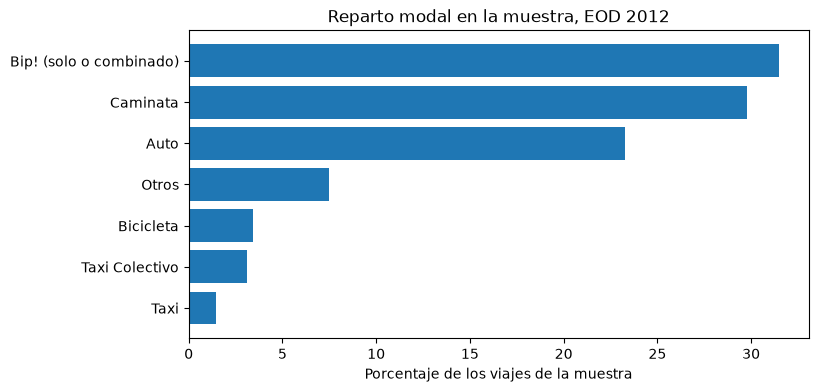

In [12]:
reparto = viajes_modo["ModoAgrupado"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(reparto.index[::-1], reparto.values[::-1])
ax.set_xlabel("Porcentaje de los viajes de la muestra")
ax.set_title("Reparto modal en la muestra, EOD 2012")
plt.show()

## 5. Variables cuantitativas: resumir y mirar la forma

`TiempoViaje` sí es una magnitud numérica: minutos de duración, una variable **continua**. Para las cuantitativas, el resumen básico es `describe`.

In [13]:
viajes["TiempoViaje"].describe().round(1)

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64

La media (36,9 minutos en la muestra) y la mediana (30) no coinciden: hay una cola de viajes largos que arrastra la media hacia arriba. Esa forma se ve mejor en un histograma:

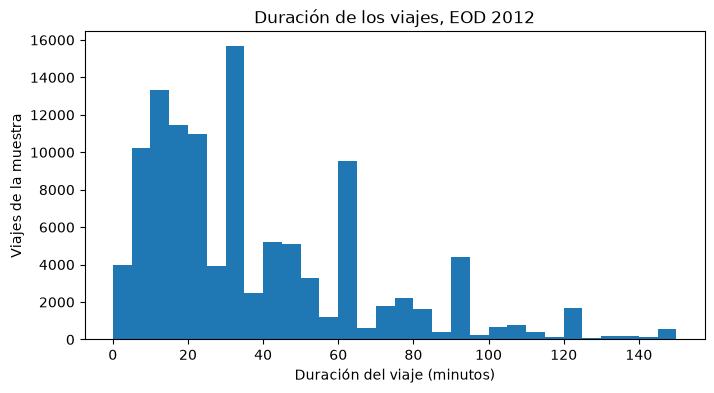

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(viajes["TiempoViaje"].dropna(), bins=30, range=(0, 150))
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Viajes de la muestra")
ax.set_title("Duración de los viajes, EOD 2012")
plt.show()

Dos aspectos del histograma: la cola larga hacia la derecha (pocos viajes muy largos) y los peaks en los múltiplos de media hora, porque las personas declaran duraciones redondeadas. En la clase 2 pondremos nombre y número a todo esto: media, mediana, dispersión, forma.

Un ejemplo de variable **discreta**, para completar el mapa de la clase: cuántos viajes hizo cada persona en el día. Se obtiene contando filas por persona, y sus valores son 1, 2, 3..., no cualquier decimal.

In [15]:
viajes_por_persona = viajes.groupby(["Hogar", "Persona"]).size()

# Cuántas personas hicieron 1, 2, 3... viajes (entre quienes viajaron)
viajes_por_persona.value_counts().sort_index().head(8)

1     1331
2    35056
3     2390
4     5199
5      823
6      881
7      241
8      206
Name: count, dtype: int64

### Transformar valores con `apply`

`apply` evalúa una función sobre cada valor de una columna. Sirve para transformaciones que no vienen hechas en Pandas, por ejemplo convertir la duración (una variable continua) en tramos (una variable ordinal):

In [16]:
def clasificar_duracion(minutos):
    if minutos <= 15:
        return "corto (hasta 15 min)"
    if minutos <= 45:
        return "medio (16 a 45 min)"
    return "largo (más de 45 min)"

tramos = viajes["TiempoViaje"].dropna().apply(clasificar_duracion)

tramos.value_counts(normalize=True).round(3)

TiempoViaje
medio (16 a 45 min)      0.386
corto (hasta 15 min)     0.339
largo (más de 45 min)    0.274
Name: proportion, dtype: float64

Para cortes por tramos existe también `pd.cut`; `apply` es la herramienta general para cualquier función propia, y la usaremos con frecuencia.

## 6. Cruzar variables: promedios por grupo

Un análisis frecuente cruza una variable cualitativa con una cuantitativa: por ejemplo, la duración de los viajes según la comuna donde parten. El patrón es `groupby` (partir la tabla en grupos) seguido del resumen que se quiera por grupo, aquí la media.

Usamos `viajes_comuna`, la tabla que ya tiene los nombres puestos:

In [17]:
duracion_comuna = (viajes_comuna
    .groupby("Comuna")["TiempoViaje"].mean()
    .sort_values(ascending=False))

# Comunas desde donde parten los viajes más largos, en promedio
duracion_comuna.head(10).round(1)

Comuna
La Pintana          45.2
Santiago            45.1
Quilicura           42.7
Padre Hurtado       42.4
Providencia         40.7
Peñaflor            40.6
Talagante           40.6
Huechuraba          40.0
Estación Central    40.0
Independencia       39.3
Name: TiempoViaje, dtype: float64

Y el otro extremo:

In [18]:
duracion_comuna.tail(10).round(1)

Comuna
Conchalí               32.7
Lampa                  32.6
Lo Prado               31.5
Cerro Navia            30.4
El Bosque              30.2
San Ramón              30.0
La Granja              29.8
San Bernardo           29.0
Pedro Aguirre Cerda    28.0
Buin                   26.4
Name: TiempoViaje, dtype: float64

Aquí sí tiene sentido promediar: `TiempoViaje` es cuantitativa, y la comuna solo define los grupos. Son medias de la muestra, sin ponderar, así que se leen como descripción de los encuestados, no de la ciudad.

Con esto queda cubierto el conjunto inicial de operaciones: contar (`value_counts`), traducir códigos (`merge`), resumir (`describe`), graficar la distribución (histograma) y comparar grupos (`groupby`).

### Tres gráficos básicos

Por ahora distinguimos tres gráficos, cada uno con su uso:

- **Barras**: conteos o proporciones de una variable cualitativa (el reparto modal de la sección 4).
- **Histograma**: la distribución de una variable cuantitativa (la duración de los viajes en la sección 5).
- **Dispersión (scatter)**: la relación entre dos variables cuantitativas.

El que falta es el de dispersión. Un ejemplo con las comunas: el número de viajes registrados contra su duración media.

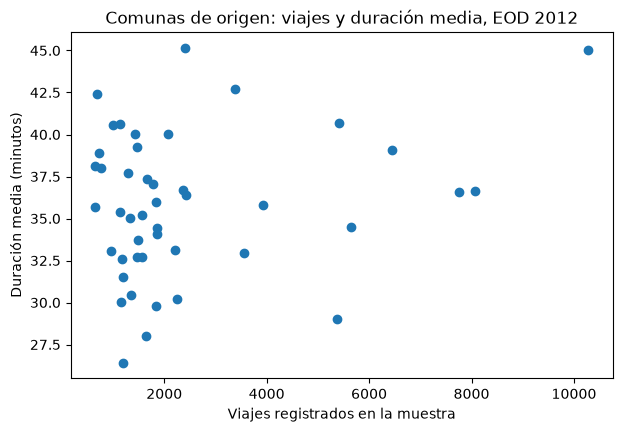

In [19]:
resumen_comuna = viajes_comuna.groupby("Comuna").agg(
    n_viajes=("Viaje", "size"), duracion_media=("TiempoViaje", "mean"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(resumen_comuna["n_viajes"], resumen_comuna["duracion_media"])
ax.set_xlabel("Viajes registrados en la muestra")
ax.set_ylabel("Duración media (minutos)")
ax.set_title("Comunas de origen: viajes y duración media, EOD 2012")
plt.show()

Cada punto es una comuna. El gráfico de dispersión es la herramienta central del análisis bivariado, que retomaremos en la clase 3 junto con la correlación.

## 7. La tabla de personas y el factor de expansión

La encuesta tiene también una tabla de personas. La abrimos y traducimos el código de `Sexo` con su tabla de parámetros, con el mismo patrón de `merge`:

In [20]:
personas = pd.read_csv(BASE + "personas.csv", sep=";", decimal=",", low_memory=False)
sexo = pd.read_csv(BASE + "tablas_parametros/Sexo.csv", sep=";")
sexo = sexo.rename(columns={"Sexo": "NombreSexo"})
personas_sexo = personas.merge(sexo, left_on="Sexo", right_on="Id")

# Proporción de hombres y mujeres en la muestra
personas_sexo["NombreSexo"].value_counts(normalize=True).round(3)

NombreSexo
Mujer     0.528
Hombre    0.472
Name: proportion, dtype: float64

Esa es la proporción **en la muestra**: 52,8% de mujeres.

### Qué es un factor de expansión

Una encuesta no entrevista a toda la población: la EOD entrevistó a 60.054 personas para representar a los cerca de 6,65 millones de habitantes que cubre. El **factor de expansión** de cada persona indica a cuántos habitantes representa, y se calcula a partir del diseño muestral (dónde vive, sexo, edad, y qué fracción de su grupo fue encuestada). Por ejemplo, una persona con factor 110 cuenta por 110 habitantes de características similares. Por construcción, la suma de todos los factores reproduce la población: en esta tabla, `Factor_LaboralNormal` suma 6.651.735.

Por eso todo resumen tiene dos versiones: la **muestral** (contar filas) y la **ponderada** (sumar factores). La proporción ponderada de sexo se obtiene así:

In [21]:
con_factor = personas_sexo.dropna(subset=["Factor_LaboralNormal"])
ponderada = con_factor.groupby("NombreSexo")["Factor_LaboralNormal"].sum()

(ponderada / ponderada.sum()).round(3)

NombreSexo
Hombre    0.485
Mujer     0.515
Name: Factor_LaboralNormal, dtype: float64

La proporción ponderada (51,5% de mujeres) difiere de la muestral en más de un punto porcentual: la muestra tiene proporcionalmente más mujeres que la población que representa. Las dos cifras responden preguntas distintas: la muestral habla de los encuestados; la ponderada, de los habitantes de Santiago. Los factores de expansión se trabajan en detalle en las clases 2 y 3.

## 8. Ejercicio

Repita el contraste muestra contra ciudad, ahora para el reparto modal: con la tabla `viajes_modo` de la sección 4 y su columna `FactorLaboralNormal`, calcule el reparto modal ponderado por `ModoAgrupado`, grafíquelo con barras y compárelo con el que obtuvimos contando filas. Debería reencontrar el 33,9% de caminata que apareció en las slides de la clase.

In [22]:
# Su solución


---

**Próxima clase (jueves 27):** estadística descriptiva: qué miden exactamente la media, la mediana y las medidas de dispersión que hoy aparecieron de pasada, y cuándo usar cada una. Traiga el entorno funcionando; si algo falló hoy, revise la sección de problemas frecuentes de la guía de instalación o escríbanos.